In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Set a random seed so the data is reproducible every time you run it
np.random.seed(42)

In [17]:
def generate_survival_data(num_patients=1000):
    print("Generating Survival Data...")
    
    # Generate basic patient info
    device_ids = [f"MD_{i:04d}" for i in range(1, num_patients + 1)]
    patient_ages = np.random.normal(loc=72, scale=12, size=num_patients).clip(20, 100)
    
    # Pacing percentage: How much the patient's heart relies on the device (0% to 100%)
    pacing_percentages = np.random.uniform(1, 100, num_patients)
    
    # Calculate "True Life" of the battery in months. 
    # Baseline ~120 months. High pacing reduces life. Add some random noise.
    base_life = 130 
    pacing_penalty = pacing_percentages * 0.45 
    noise = np.random.normal(loc=0, scale=8, size=num_patients)
    true_battery_life = base_life - pacing_penalty + noise
    
    # Simulate how long ago the device was implanted (Observation Window)
    # Between 10 and 150 months ago
    months_since_implant = np.random.uniform(10, 150, num_patients)
    
    # Determine if the battery actually died, or if it's still running
    event_occurred = []
    observed_duration = []
    
    for true_life, implant_duration in zip(true_battery_life, months_since_implant):
        if true_life <= implant_duration:
            # Battery died before our observation window ended
            event_occurred.append(1) 
            observed_duration.append(true_life)
        else:
            # Battery is still alive today (Right-Censored)
            event_occurred.append(0)
            observed_duration.append(implant_duration)
            
    # Create DataFrame
    df_survival = pd.DataFrame({
        'Device_ID': device_ids,
        'Patient_Age': np.round(patient_ages, 1),
        'Pacing_Percentage': np.round(pacing_percentages, 1),
        'Duration_Months': np.round(observed_duration, 1),
        'Event_Occurred': event_occurred
    })
    
    return df_survival

df_survival = generate_survival_data()
print("Survival Data Generated!")
print(df_survival.head(), "\n")

Generating Survival Data...
Survival Data Generated!
  Device_ID  Patient_Age  Pacing_Percentage  Duration_Months  Event_Occurred
0   MD_0001         82.7               18.8            120.1               1
1   MD_0002         65.8               43.1            105.1               1
2   MD_0003         84.3               75.7             43.8               0
3   MD_0004         72.7               84.2            100.6               1
4   MD_0005         70.0               97.9             89.7               1 



In [14]:
def generate_spc_data():
    print("Generating Time-Series SPC Data...")
    
    # Select 5 devices to monitor over 30 days
    spc_devices = [f"MD_{i:04d}" for i in range(1, 6)]
    end_date = datetime.today()
    dates = [end_date - timedelta(days=x) for x in range(30)][::-1] # Reverse to go past -> present
    
    records = []
    
    for dev in spc_devices:
        # Each patient has a slightly different baseline impedance (e.g., 450 to 550 ohms)
        baseline_impedance = np.random.uniform(450, 550)
        
        # Generate 30 days of normal readings (slight daily noise)
        impedances = np.random.normal(loc=baseline_impedance, scale=8, size=30)
        
        # Battery voltage over 30 days is basically flat, just tiny sensor noise
        voltages = np.random.normal(loc=2.75, scale=0.02, size=30)
        
        # ⚠️ INJECT ANOMALY: Make Device MD_0003 experience a lead fracture on Day 25
        if dev == "MD_0003":
            impedances[24:] += 180  # Sudden massive spike in impedance
            
        for i, date in enumerate(dates):
            records.append({
                'Date': date.strftime("%Y-%m-%d"),
                'Device_ID': dev,
                'Lead_Impedance_Ohms': np.round(impedances[i], 1),
                'Battery_Voltage_V': np.round(voltages[i], 2)
            })
            
    df_spc = pd.DataFrame(records)
    return df_spc

df_spc = generate_spc_data()
print("SPC Data Generated!")
print(df_spc[df_spc['Device_ID'] == 'MD_0003'].tail(50)) # Look at the end of MD_0003 to see the spike

Generating Time-Series SPC Data...
SPC Data Generated!
          Date Device_ID  Lead_Impedance_Ohms  Battery_Voltage_V
60  2026-05-19   MD_0003                462.1               2.74
61  2026-05-20   MD_0003                458.0               2.76
62  2026-05-21   MD_0003                461.5               2.78
63  2026-05-22   MD_0003                465.1               2.77
64  2026-05-23   MD_0003                462.0               2.78
65  2026-05-24   MD_0003                454.5               2.73
66  2026-05-25   MD_0003                454.6               2.76
67  2026-05-26   MD_0003                448.2               2.75
68  2026-05-27   MD_0003                452.8               2.76
69  2026-05-28   MD_0003                475.4               2.78
70  2026-05-29   MD_0003                453.3               2.75
71  2026-05-30   MD_0003                450.1               2.74
72  2026-05-31   MD_0003                462.2               2.76
73  2026-06-01   MD_0003           

In [20]:
# Save to CSV
df_survival.to_csv('pacemaker_survival_data.csv', index=False)
df_spc.to_csv('pacemaker_spc_data.csv', index=False)

print("\nSuccess: Both datasets saved as CSVs. Day 1 complete!")


Success: Both datasets saved as CSVs. Day 1 complete!


In [18]:
pip install lifelines matplotlib seaborn

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4138 sha256=fcee1e9d8f4f451b63fdbab3275c563e06909edefbf1f6ae40a83126b6103551
  Stored in directory: c:\users\stranger things\appdata\local\pip\cache\wheels\7e\16\46\9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma

   ---------------------------------------- 0/5 [interface-meta]
   ---------------------------------------- 0/5 [interface-meta]
   ---------------------------------------- 0/5 [interface-meta]
   -------- ------------------------------- 1/5 [autograd]
   -------- ------------------------------- 1/5 [autograd]
   -------- ------------------------------- 1/5 [autograd]
   -------- ------------------------------- 1/5 [autograd]
   -------- ------------------------------- 1/5 [autograd]
   -------- ------------------------------- 1/5 [autograd]
   -------

  DEPRECATION: Building 'autograd-gamma' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'autograd-gamma'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


--- SURVIVAL ANALYSIS ---


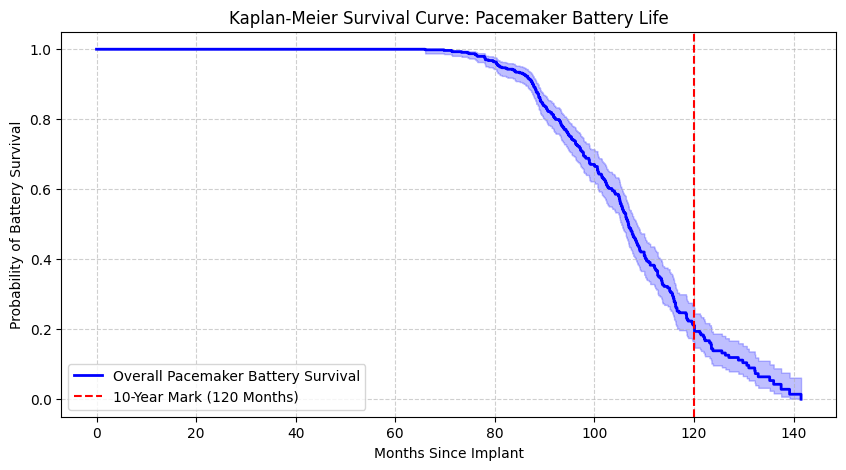


Cox Proportional Hazards Summary:


<lifelines.CoxPHFitter: fitted with 1000 total observations, 711 right-censored observations>
             duration col = 'Duration_Months'
                event col = 'Event_Occurred'
      baseline estimation = breslow
   number of observations = 1000
number of events observed = 289
   partial log-likelihood = -1275.86
         time fit was run = 2026-06-17 11:24:58 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
Patient_Age       -0.01      0.99      0.00           -0.02            0.00                0.98                1.00
Pacing_Percentage  0.06      1.06      0.00            0.05            0.06                1.05                1.06

                   cmp to     z      p  -log2(p)
covariate                                       
Patient_Age          0.00 -1.57   0.12      3.10
Pacing_Percentage    0.00 18.15 <0.005    242.10
---
Concordance = 0.86
Partial AIC = 2555.73
log-likelihood ratio test = 394.53 on 2 df
-log2(p) of ll-ratio test = 284.59

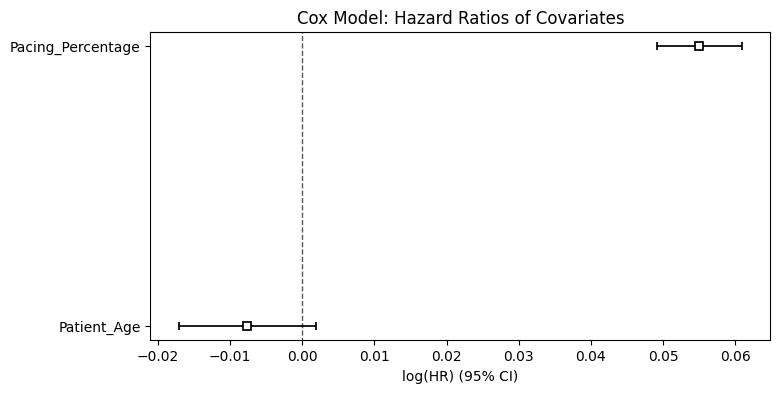

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter

# 1. Load the Survival Data
df_surv = pd.read_csv('pacemaker_survival_data.csv')

print("--- SURVIVAL ANALYSIS ---")

# ==========================================
# MODEL A: Kaplan-Meier Survival Curve
# ==========================================
kmf = KaplanMeierFitter()

# Fit the model using Duration and Event (1 = Dead, 0 = Censored/Alive)
kmf.fit(durations=df_surv['Duration_Months'], 
        event_observed=df_surv['Event_Occurred'], 
        label='Overall Pacemaker Battery Survival')

# Plot the curve
plt.figure(figsize=(10, 5))
kmf.plot_survival_function(color='blue', linewidth=2)
plt.title('Kaplan-Meier Survival Curve: Pacemaker Battery Life')
plt.xlabel('Months Since Implant')
plt.ylabel('Probability of Battery Survival')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=120, color='red', linestyle='--', label='10-Year Mark (120 Months)')
plt.legend()
plt.show()

# ==========================================
# MODEL B: Cox Proportional Hazards Model
# ==========================================
cph = CoxPHFitter()

# We drop the Device_ID because it's just a label, not a statistical variable
df_cox = df_surv.drop('Device_ID', axis=1)

# Fit the Cox model
cph.fit(df_cox, duration_col='Duration_Months', event_col='Event_Occurred')

print("\nCox Proportional Hazards Summary:")
# Print the statistical summary (Hazard Ratios, p-values)
cph.print_summary()

# Plot the hazard ratios
plt.figure(figsize=(8, 4))
cph.plot()
plt.title('Cox Model: Hazard Ratios of Covariates')
plt.show()


--- STATISTICAL PROCESS CONTROL (SPC) ---
Healthy Baseline Mean: 458.95 Ohms
Upper Control Limit (UCL): 479.00 Ohms
Lower Control Limit (LCL): 438.90 Ohms


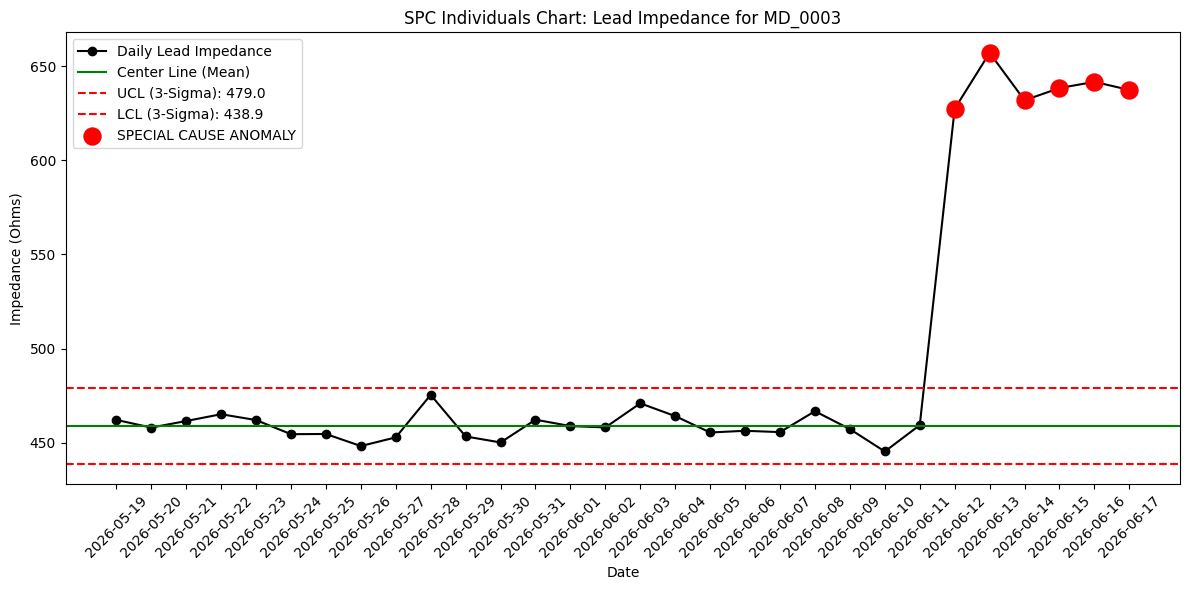

In [7]:
import numpy as np

# 2. Load the Time-Series SPC Data
df_spc = pd.read_csv('pacemaker_spc_data.csv')

print("\n--- STATISTICAL PROCESS CONTROL (SPC) ---")

# Isolate the device with the injected anomaly
device_id = "MD_0003"
df_device = df_spc[df_spc['Device_ID'] == device_id].copy()
df_device = df_device.sort_values('Date').reset_index(drop=True)

# ---------------------------------------------------------
# SPC MATH: Calculate Baseline Mean and Control Limits
# ---------------------------------------------------------
# We use the first 20 days as the "Healthy Baseline" to establish our control limits
baseline_data = df_device.iloc[:20]['Lead_Impedance_Ohms']

mean_impedance = baseline_data.mean()
std_impedance = baseline_data.std()

# 3-Sigma Rule for Upper and Lower Control Limits (UCL / LCL)
UCL = mean_impedance + (3 * std_impedance)
LCL = mean_impedance - (3 * std_impedance)

print(f"Healthy Baseline Mean: {mean_impedance:.2f} Ohms")
print(f"Upper Control Limit (UCL): {UCL:.2f} Ohms")
print(f"Lower Control Limit (LCL): {LCL:.2f} Ohms")

# Identify anomalies: any point outside the control limits
df_device['Out_Of_Control'] = (df_device['Lead_Impedance_Ohms'] > UCL) | (df_device['Lead_Impedance_Ohms'] < LCL)

# ---------------------------------------------------------
# Plotting the SPC Control Chart
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot the actual daily telemetry data
plt.plot(df_device['Date'], df_device['Lead_Impedance_Ohms'], marker='o', color='black', label='Daily Lead Impedance')

# Plot SPC Limits
plt.axhline(mean_impedance, color='green', linestyle='-', label='Center Line (Mean)')
plt.axhline(UCL, color='red', linestyle='--', label=f'UCL (3-Sigma): {UCL:.1f}')
plt.axhline(LCL, color='red', linestyle='--', label=f'LCL (3-Sigma): {LCL:.1f}')

# Highlight the anomalies in bright red
anomalies = df_device[df_device['Out_Of_Control']]
plt.scatter(anomalies['Date'], anomalies['Lead_Impedance_Ohms'], color='red', s=150, zorder=5, label='SPECIAL CAUSE ANOMALY')

plt.title(f'SPC Individuals Chart: Lead Impedance for {device_id}')
plt.xlabel('Date')
plt.ylabel('Impedance (Ohms)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)